In [ ]:
import sys
import heapq
import time
import random
from pathlib import Path
from collections import defaultdict

# Setup repo root for imports
repo_root = Path.cwd()
while not (repo_root / "csp.py").exists():
    parent = repo_root.parent
    if parent == repo_root:
        break
    repo_root = parent
if str(repo_root) not in sys.path:
    sys.path.append(str(repo_root))

from csp import CSP, backtracking_search, mrv, mac, unordered_domain_values

### Flight Ground Service Scheduling (COP)

This model addresses the problem of scheduling multiple task types (CLEAN, FUEL, BAGGAGE) for arriving flights. We aim to minimize the number of worker teams required for each task type.

**Problem Formulation:**
- **Variables:** Task instances $(f, t)$ where $f$ is a flight and $t$ is a task type.
- **Domains:** Team IDs $\{1, 2, \dots, U_t\}$.
- **Constraints:** Overlapping tasks of the same type must be assigned different teams.
- **Objective:** Minimize the total number of teams used.

Following **Solution A** from the context, we use a **Greedy Interval Partitioning** approach, which is optimal for fixed-interval scheduling.

In [16]:
# plotter function

import matplotlib.pyplot as plt

def plot_ground_service_schedule(instances, assignments, team_counts):
    fig, ax = plt.subplots(figsize=(12, 8))
    
    colors = {
        "CLEAN": "skyblue", 
        "FUEL": "orange", 
        "BAGGAGE": "lightgreen",
        "RAMP": "pink",
        "BOARD": "yellow"
    }
    
    # Calculate y-offsets to separate task types and teams
    y_base = 0
    type_offsets = {}
    for t in task_types:
        type_offsets[t] = y_base
        y_base += team_counts.get(t, 0) + 1
        
    for inst in instances:
        t_type = inst["type"]
        team_id = assignments.get(inst["id"])
        if team_id is None: continue
        
        y_pos = type_offsets[t_type] + (team_id - 1)
        
        ax.barh(y_pos, inst["end"] - inst["start"], left=inst["start"], 
                color=colors.get(t_type, "gray"), edgecolor='black', alpha=0.8)
        ax.text(inst["start"] + 0.1, y_pos, f"{inst['id']} (T{team_id})", 
                va='center', fontsize=7, fontweight='bold')

    # Formatting
    ax.set_xlabel("Time")
    ax.set_ylabel("Task Types and Teams")
    ax.set_title("Flight Ground Service Schedule (Solution A)")
    
    # Set y-ticks to show task types
    tick_positions = [type_offsets[t] + (team_counts.get(t, 1)-1)/2 for t in task_types]
    ax.set_yticks(tick_positions)
    ax.set_yticklabels(task_types)
    
    ax.grid(True, axis='x', linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()



--- Solution A: Greedy Interval Partitioning Results ---
Task Type: CLEAN    | Teams Needed: 4
Task Type: FUEL     | Teams Needed: 4
Task Type: BAGGAGE  | Teams Needed: 3
Task Type: RAMP     | Teams Needed: 5
Task Type: BOARD    | Teams Needed: 2

Total Resources (Sum of N_t): 18


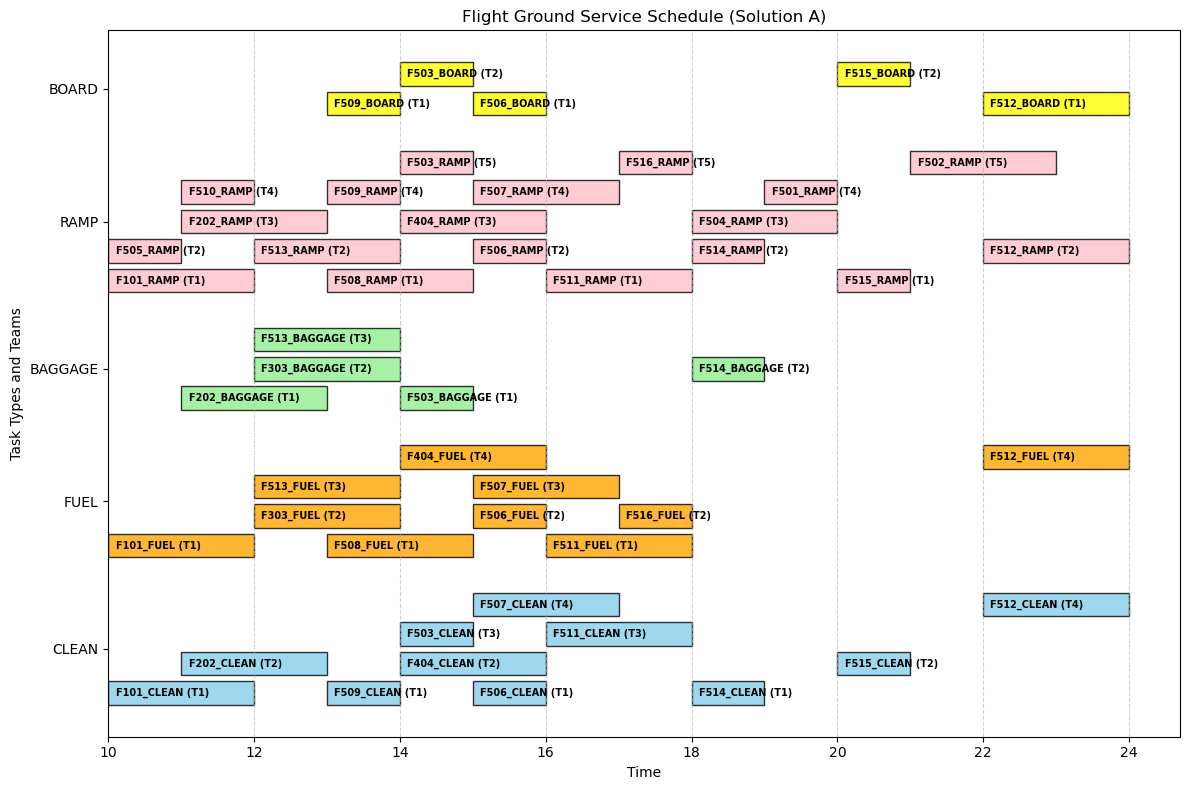

In [17]:
# solve and plot the tasks (greedy partition)

# 1. Define Input Data
flights = {
    "F101": {"start": 10, "end": 12, "tasks": ["CLEAN", "FUEL","RAMP"]},
    "F505": {"start": 10, "end": 11, "tasks": ["RAMP"]},
    "F202": {"start": 11, "end": 13, "tasks": ["CLEAN", "BAGGAGE", "RAMP"]},
    "F510": {"start": 11, "end": 12, "tasks": ["RAMP"]},
    "F303": {"start": 12, "end": 14, "tasks": ["FUEL", "BAGGAGE"]},
    "F513": {"start": 12, "end": 14, "tasks": ["FUEL", "RAMP", "BAGGAGE"]},
    "F508": {"start": 13, "end": 15, "tasks": ["FUEL", "RAMP"]},
    "F509": {"start": 13, "end": 14, "tasks": ["CLEAN", "BOARD", "RAMP"]},
    "F404": {"start": 14, "end": 16, "tasks": ["CLEAN", "FUEL", "RAMP"]},
    "F503": {"start": 14, "end": 15, "tasks": ["CLEAN", "BOARD", "RAMP", "BAGGAGE"]},
    "F506": {"start": 15, "end": 16, "tasks": ["FUEL", "CLEAN", "BOARD", "RAMP"]},
    "F507": {"start": 15, "end": 17, "tasks": ["CLEAN", "FUEL", "RAMP"]},
    "F511": {"start": 16, "end": 18, "tasks": ["CLEAN", "FUEL", "RAMP"]},
    "F516": {"start": 17, "end": 18, "tasks": ["FUEL", "RAMP"]},
    "F514": {"start": 18, "end": 19, "tasks": ["CLEAN", "RAMP", "BAGGAGE"]},
    "F504": {"start": 18, "end": 20, "tasks": ["RAMP"]},
    "F501": {"start": 19, "end": 20, "tasks": ["RAMP"]},
    "F515": {"start": 20, "end": 21, "tasks": ["CLEAN", "BOARD", "RAMP"]},
    "F502": {"start": 21, "end": 23, "tasks": ["RAMP"]},
    "F512": {"start": 22, "end": 24, "tasks": ["FUEL", "CLEAN", "BOARD", "RAMP"]},
}

task_types = ["CLEAN", "FUEL", "BAGGAGE", "RAMP", "BOARD"]

# 2. Build Task Instances
task_instances = []
for f_id, info in flights.items():
    for t_type in info["tasks"]:
        task_instances.append({
            "id": f"{f_id}_{t_type}",
            "flight": f_id,
            "type": t_type,
            "start": info["start"],
            "end": info["end"]
        })

def solve_solution_a_greedy(instances, t_type):
    """
    Implementation of Solution A: Per-task-type greedy interval partitioning.
    Optimal for fixed intervals.
    """
    # Filter tasks by type
    type_tasks = [inst for inst in instances if inst["type"] == t_type]
    if not type_tasks:
        return {}, 0
    
    # Sort by start time
    sorted_tasks = sorted(type_tasks, key=lambda x: x["start"])
    
    # Min-heap of (end_time, team_id)
    # Note: Context defines overlap as [s, e] intersection. 
    # So a team is free only if free_time < start_time.
    teams_heap = [] 
    assignments = {}
    team_count = 0
    
    for task in sorted_tasks:
        # If earliest team is free strictly before task starts (no overlap at boundary)
        if teams_heap and teams_heap[0][0] < task["start"]:
            free_time, team_id = heapq.heappop(teams_heap)
            assignments[task["id"]] = team_id
            heapq.heappush(teams_heap, (task["end"], team_id))
        else:
            # Need a new team
            team_count += 1
            assignments[task["id"]] = team_count
            heapq.heappush(teams_heap, (task["end"], team_count))
            
    return assignments, team_count

# Execute Solution A
all_assignments = {}
total_teams_needed = {}

print("--- Solution A: Greedy Interval Partitioning Results ---")
for t in task_types:
    assigns, count = solve_solution_a_greedy(task_instances, t)
    all_assignments.update(assigns)
    total_teams_needed[t] = count
    print(f"Task Type: {t:<8} | Teams Needed: {count}")

print(f"\nTotal Resources (Sum of N_t): {sum(total_teams_needed.values())}")

plot_ground_service_schedule(task_instances, all_assignments, total_teams_needed)

### Solution B: CSP Formulation

This approach models the problem as a formal Constraint Satisfaction Problem. We define variables for each task and use binary constraints to enforce that overlapping tasks of the same type are assigned to different teams. To minimize the number of teams ($N_t$), we iteratively search for a valid assignment starting from one team and increasing the count until a solution is found.

--- Solution B: CSP Solver Results ---
Task Type: CLEAN    | Teams Needed: 4
Task Type: FUEL     | Teams Needed: 4
Task Type: BAGGAGE  | Teams Needed: 3
Task Type: RAMP     | Teams Needed: 5
Task Type: BOARD    | Teams Needed: 2

Total Resources (Sum of N_t): 18


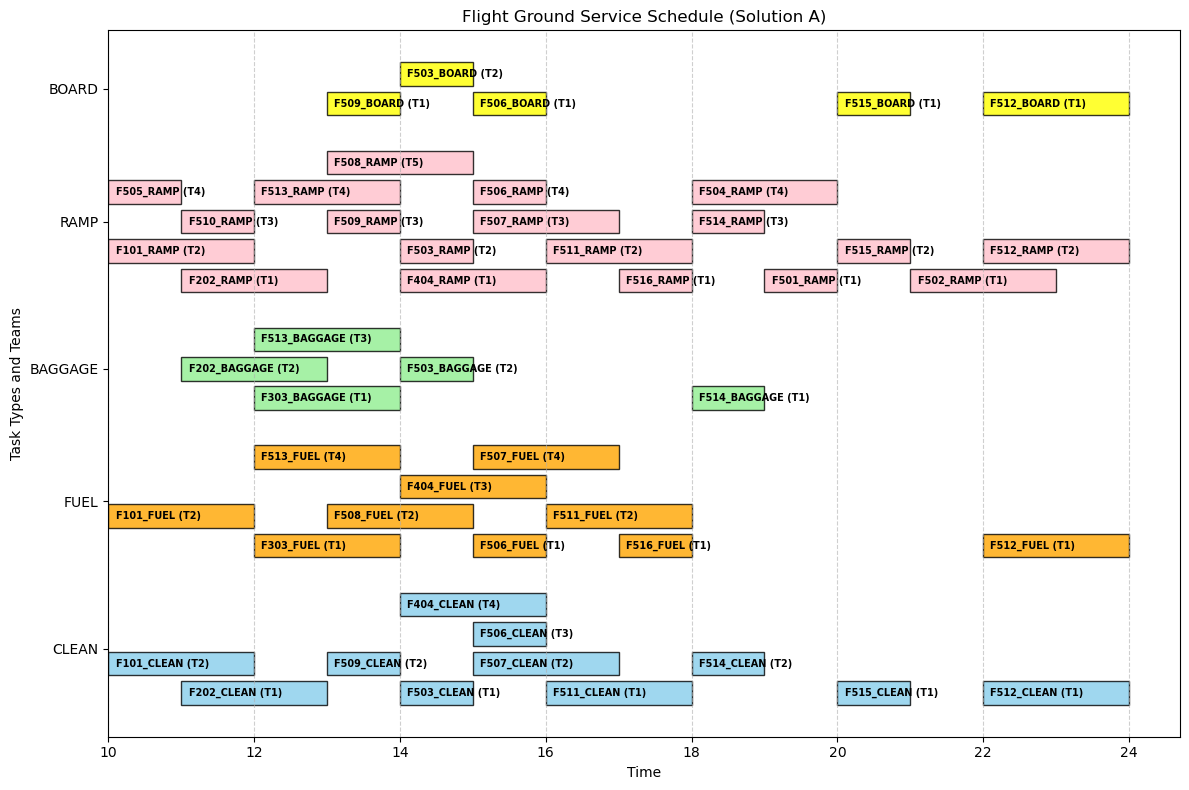

In [18]:
from csp import different_values_constraint

def solve_solution_b_csp():
    all_b_assignments = {}
    total_b_teams = {}
    
    for t_type in task_types:
        # Filter tasks for this specific type
        type_tasks = [inst for inst in task_instances if inst["type"] == t_type]
        if not type_tasks:
            continue
            
        task_ids = [inst["id"] for inst in type_tasks]
        
        # Build constraint graph: edges between overlapping tasks
        neighbors = {tid: [] for tid in task_ids}
        for i in range(len(type_tasks)):
            for j in range(i + 1, len(type_tasks)):
                t1, t2 = type_tasks[i], type_tasks[j]
                # Overlap check: intersection of [s1, e1] and [s2, e2] is non-empty
                if max(t1["start"], t2["start"]) <= min(t1["end"], t2["end"]):
                    neighbors[t1["id"]].append(t2["id"])
                    neighbors[t2["id"]].append(t1["id"])
        
        # Iteratively find the minimum number of teams (n)
        for n in range(1, len(type_tasks) + 1):
            domains = {tid: list(range(1, n + 1)) for tid in task_ids}
            
            # Create CSP instance
            problem = CSP(task_ids, domains, neighbors, different_values_constraint)
            
            # Solve using backtracking with MRV and MAC inference
            solution = backtracking_search(problem, select_unassigned_variable=mrv, inference=mac)
            
            if solution:
                all_b_assignments.update(solution)
                total_b_teams[t_type] = n
                break
                
    return all_b_assignments, total_b_teams

# Execute Solution B
all_b_assignments, total_b_teams = solve_solution_b_csp()

print("--- Solution B: CSP Solver Results ---")
for t in task_types:
    print(f"Task Type: {t:<8} | Teams Needed: {total_b_teams.get(t, 0)}")

print(f"\nTotal Resources (Sum of N_t): {sum(total_b_teams.values())}")

# Reuse visualization for Solution B
plot_ground_service_schedule(task_instances, all_b_assignments, total_b_teams)